In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
import h5py

In [ ]:
with h5py.File('./raw/observations_deV_with_SL2S_mass_grids.hdf5', 'r') as f:
    m5_mid, m5_low, m5_up = np.zeros((3, len(f.keys())))
    m10_mid, m10_low, m10_up = np.zeros((3, len(f.keys())))
    gamma_mid, gamma_low, gamma_up = np.zeros((3, len(f.keys())))
    logmstar = np.zeros(len(f.keys()))
    logre_kpc = np.zeros(len(f.keys()))
    for i, name in enumerate(f.keys()):
        grp = f[name]
        m5_mid[i] = grp.attrs['m5_mid']
        m5_low[i] = grp.attrs['m5_lower']
        m5_up[i] = grp.attrs['m5_upper']
        m10_mid[i] = grp.attrs['m10_mid']
        m10_low[i] = grp.attrs['m10_lower']
        m10_up[i] = grp.attrs['m10_upper']
        gamma_mid[i] = grp.attrs['gamma_mid']
        gamma_low[i] = grp.attrs['gamma_lower']
        gamma_up[i] = grp.attrs['gamma_upper']
        logmstar[i] = grp.attrs['logmchab_deV']
        re = grp.attrs['reff_deV']
        re_kpc = re * cosmo.kpc_proper_per_arcmin(grp.attrs['zd']).value / 60
        logre_kpc[i] = np.log10(re_kpc)
        if logmstar[i] > 12:
            print(name, logmstar[i])

with h5py.File('./raw/observations_deV_with_mass_grids.hdf5', 'r') as f:
    m5_mid2, m5_low2, m5_up2 = np.zeros((3, 7))
    m10_mid2, m10_low2, m10_up2 = np.zeros((3, 7))
    gamma_mid2, gamma_low2, gamma_up2 = np.zeros((3, 7))
    logmstar2 = np.zeros(7)
    logre_kpc2 = np.zeros(7)
    i = 0
    for _, name in enumerate(f.keys()):
        grp = f[name]
        num_sigma = grp.attrs['num_sigma'][()]
        if num_sigma >= 1:
            print(name, num_sigma)
            m5_mid2[i] = grp.attrs['m5_mid']
            m5_low2[i] = grp.attrs['m5_lower']
            m5_up2[i] = grp.attrs['m5_upper']
            m10_mid2[i] = grp.attrs['m10_mid']
            m10_low2[i] = grp.attrs['m10_lower']
            m10_up2[i] = grp.attrs['m10_upper']
            gamma_mid2[i] = grp.attrs['gamma_mid']
            gamma_low2[i] = grp.attrs['gamma_lower']
            gamma_up2[i] = grp.attrs['gamma_upper']
            logmstar2[i] = grp.attrs['logmchab_deV']
            re = grp.attrs['reff_deV']
            re_kpc = re * cosmo.kpc_proper_per_arcmin(grp.attrs['zd']).value / 60
            logre_kpc2[i] = np.log10(re_kpc)
            i+=1

023817-054555 2
121052-011905 1
140929-011410 1
141300-012608 1
142720+001916 1
222801+012805 2
223733+005015 2
223733+005015 11.46


In [13]:
logmstar2

array([11.58, 11.52, 11.32, 11.5 , 11.53, 11.63, 11.46])

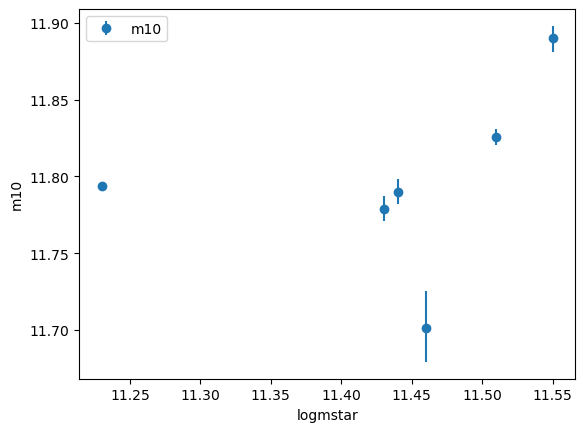

In [14]:
plt.errorbar(logmstar, m10_mid, yerr=[m10_low, m10_up], fmt='o', label='m10')
plt.xlabel('logmstar')
plt.ylabel('m10')
plt.legend()

<ErrorbarContainer object of 3 artists>

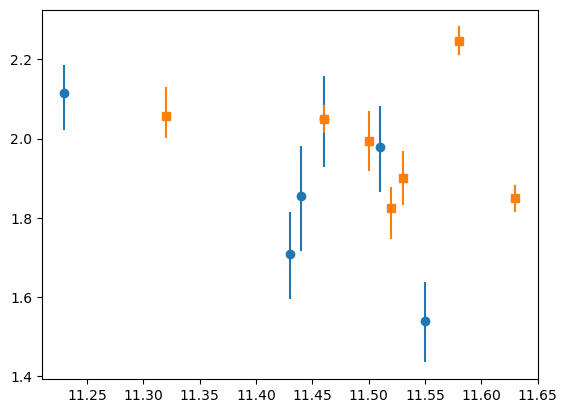

In [15]:
plt.errorbar(logmstar,gamma_mid, yerr=[gamma_low, gamma_up], fmt='o', label='gamma')
plt.errorbar(logmstar2, gamma_mid2, yerr=[gamma_low2, gamma_up2], fmt='s', label='gamma (with mass grids)')